In [3]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import *
from utils import *

In [4]:
# load returns.csv
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)
returns.tz_localize('UTC', axis='index')
print(returns.info())
returns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2639 entries, 2014-01-03 to 2024-06-28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2639 non-null   float64
 1   AMZN    2639 non-null   float64
dtypes: float64(2)
memory usage: 61.9 KB
None


,SPY,AMZN
Date,,
2014-01-03,-0.384451,-0.016418
2014-01-06,-0.708814,-0.289787
2014-01-07,1.117807,0.614204
2014-01-08,0.977313,0.021748
2014-01-09,-0.226412,0.065415
...,...,...
2024-06-24,-1.856354,-0.325068
2024-06-25,0.414932,0.385090
2024-06-26,3.901473,0.124817


In [5]:
# Split data into train, validation, and test sets
train_split = '2022-01-01'
val_split = '2023-01-01' 
train = returns.loc[:train_split]
val = returns.loc[train_split:val_split]
test = returns.loc[val_split:]


# check

print(train.shape, val.shape, test.shape)
print(train.index.min(), train.index.max())
print(val.index.min(), val.index.max())
print(test.index.min(), test.index.max())

print("Train")
print(train)
print("Validation")
print(val)
print("Test")
print(test)


(2014, 2) (251, 2) (374, 2)
2014-01-03 00:00:00 2021-12-31 00:00:00
2022-01-03 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2024-06-28 00:00:00
Train
                 SPY      AMZN
Date                          
2014-01-03 -0.384451 -0.016418
2014-01-06 -0.708814 -0.289787
2014-01-07  1.117807  0.614204
2014-01-08  0.977313  0.021748
2014-01-09 -0.226412  0.065415
...              ...       ...
2021-12-27 -0.817802  1.415238
2021-12-28  0.584372 -0.081734
2021-12-29 -0.855492  0.127921
2021-12-30 -0.328901 -0.276441
2021-12-31 -1.142940 -0.252022

[2014 rows x 2 columns]
Validation
                 SPY      AMZN
Date                          
2022-01-03  2.211832  0.578985
2022-01-04 -1.691559 -0.033484
2022-01-05 -1.889309 -1.920216
2022-01-06 -0.671098 -0.093940
2022-01-07 -0.428778 -0.395354
...              ...       ...
2022-12-23  1.742450  0.575232
2022-12-27 -2.592374 -0.394339
2022-12-28 -1.469173 -1.242806
2022-12-29  2.884381  1.800045
2022-12-30 -0.213828 -0.263407

[25

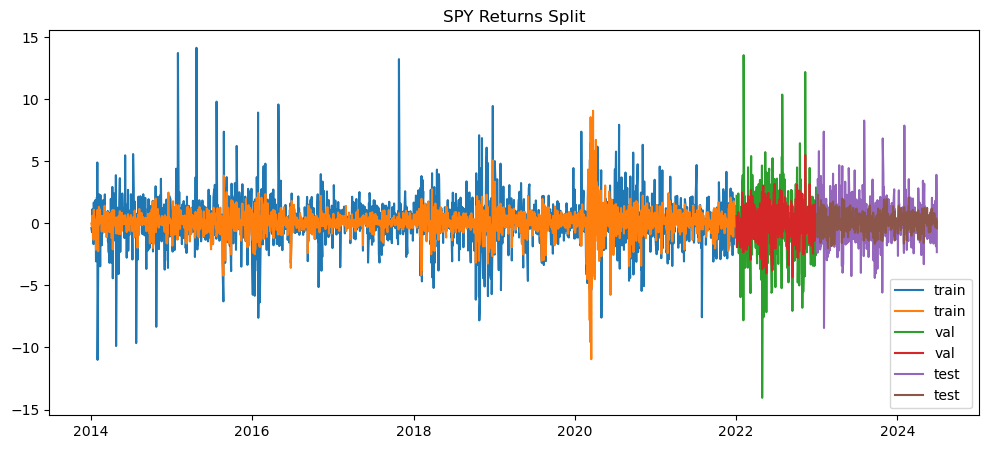

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="train")
plt.plot(val.index, val, label="val")
plt.plot(test.index, test, label="test")
plt.title("SPY Returns Split")
plt.legend()
plt.show()

In [7]:
returns.reset_index(inplace=True)
train.reset_index(inplace=True)
val.reset_index(inplace=True)
test.reset_index(inplace=True)

In [30]:
series_ts = TimeSeries.from_dataframe(
    returns,
    time_col='Date',
    value_cols=['SPY', 'AMZN'],
    # fill_missing_dates=True,
    fillna_value=0.0,
    freq='B'
).astype(np.float32)

train_ts = TimeSeries.from_dataframe(
    train, 
    time_col='Date', 
    value_cols=['SPY', 'AMZN'], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

val_ts = TimeSeries.from_dataframe(
    val, 
    time_col='Date', 
    value_cols=['SPY', 'AMZN'], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )
    
test_ts = TimeSeries.from_dataframe(
    test, 
    time_col='Date', 
    value_cols=['SPY', 'AMZN'], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

In [31]:
train_ts

,SPY,AMZN
Date,,
2014-01-03,-0.384451,-0.016418
2014-01-06,-0.708814,-0.289787
2014-01-07,1.117807,0.614204
2014-01-08,0.977313,0.021748
2014-01-09,-0.226412,0.065415
...,...,...
2021-12-27,-0.817802,1.415238
2021-12-28,0.584372,-0.081734
2021-12-29,-0.855492,0.127921


In [32]:
print(series_ts['SPY'].to_series().isna().sum())
series_ts['SPY'].to_series()[series_ts['SPY'].to_series().isna()]

0


Series([], Freq: B, Name: SPY, dtype: float32)

In [33]:
# Scaler
scaler = Scaler(MinMaxScaler(feature_range=(-1,1))) 

train_scaled = scaler.fit_transform(train_ts)
val_scaled = scaler.transform(val_ts)
test_scaled = scaler.transform(test_ts)
series_scaled = scaler.transform(series_ts)

In [34]:
# Define nbeats model
seed = 42
nbeats_name = "nbeats_spy"

model_nbeats = NBEATSModel(
    input_chunk_length=20,       # use last 20 observations
    output_chunk_length=1,       # forecast 1 step ahead
    generic_architecture=True,
    num_stacks=2,
    num_blocks=2,
    num_layers=2,
    layer_widths=64,
    n_epochs=10, 
    batch_size=32,
    random_state=seed,
    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True,
)

# fit model
history = model_nbeats.fit(
    train_scaled, 
    val_series=val_scaled,
    verbose=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 30.7 K | train
-------------------------------------------------------------
30.2 K    Trainable params
565       Non-trainable params
30.7 K    Total params
0.123     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [35]:
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=nbeats_name, best=True)

In [36]:
one_pred = model_nbeats.predict(n=1, series=train_scaled)
print(one_pred) 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

                 SPY      AMZN
Date                          
2022-01-03 -0.114246  0.096336

shape: (1, 2, 1), freq: B, size: 16.00 B


In [37]:
print(len(train), len(val), len(test))

2014 251 374


In [38]:
print(series_scaled.start_time(), series_scaled.end_time())
print(test['Date'].iloc[0])

2014-01-03 00:00:00 2024-06-28 00:00:00
2023-01-03 00:00:00


In [62]:
# historical_forecasts rolls forward through the test period
pred_scaled = model_nbeats.historical_forecasts(
    series=series_scaled,
    start=test['Date'].iloc[0],
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=False,
    verbose=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [66]:
pred_ts = scaler.inverse_transform(pred_scaled) 
print(type(pred_scaled))
print(type(pred_ts))
print(type(test_ts))

print(pred_scaled)
print(pred_ts)
print(test_ts)

<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
                 SPY      AMZN
Date                          
2023-01-03 -0.096663  0.133915
2023-01-04 -0.120676  0.064336
2023-01-05 -0.091065  0.112694
2023-01-06 -0.105106  0.084277
2023-01-09 -0.101232  0.071675
...              ...       ...
2024-06-24 -0.123008  0.078416
2024-06-25 -0.119025  0.102212
2024-06-26 -0.111717  0.099109
2024-06-27 -0.095663  0.087205
2024-06-28 -0.085317  0.082750

shape: (389, 2, 1), freq: B, size: 6.08 KB
                 SPY      AMZN
Date                          
2023-01-03  0.352448  0.398309
2023-01-04  0.050741 -0.297574
2023-01-05  0.422781  0.186064
2023-01-06  0.246365 -0.098139
2023-01-09  0.295039 -0.224173
...              ...       ...
2024-06-24  0.021448 -0.156762
2024-06-25  0.071492  0.081237
2024-06-26  0.163308  0.050198
2024-06-27  0.365010 -0.068859
2024-06-28  0.495008 -0.113414

shape: (389, 2, 1), freq: B, size: 

In [ ]:
# evaluate model
scores = {}
names = ['SPY', 'AMZN']
for name in names:   
    rootmeansquarederr = rmse(test_ts, pred_ts)
    sMAPE = smape(test_ts, pred_ts)

    scores[name] = {'RMSE': rootmeansquarederr, 'sMAPE': sMAPE}
    # print("RMSE:", rootmeansquarederr)
    # print("SMAPE :", sMAPE)

scores

SPY
AMZN


{'SPY': {'RMSE': np.float64(1.3375222330691057),
  'sMAPE': np.float64(165.0831020014951)},
 'AMZN': {'RMSE': np.float64(1.3375222330691057),
  'sMAPE': np.float64(165.0831020014951)}}

In [75]:
# scores to data
scores_df = pd.DataFrame.from_dict(scores, orient='index') 

# save scores
scores_df.to_csv('../results/tables/nbeats_scores.csv')
scores_df

,RMSE,sMAPE
SPY,1.337522,165.083102
AMZN,1.337522,165.083102


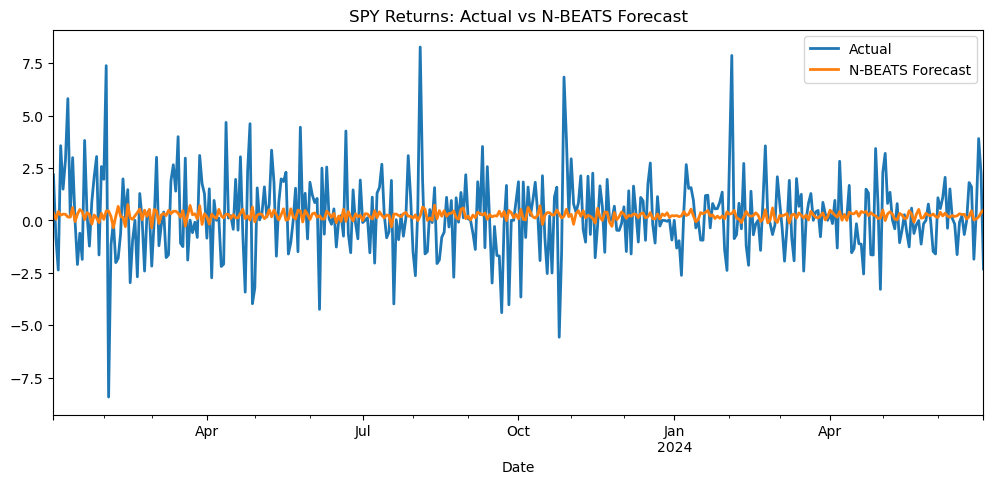

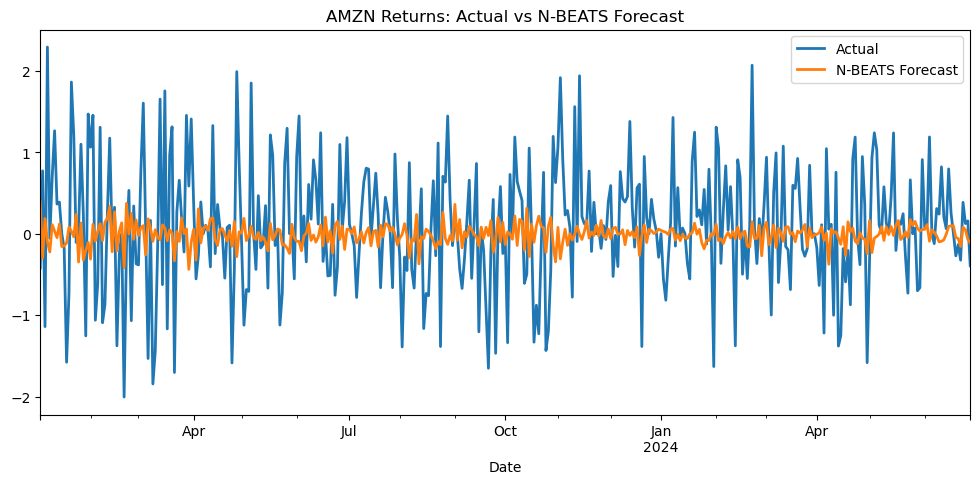

In [69]:
names = ['SPY', 'AMZN']
for name in names:
    plt.figure(figsize=(12, 5))
    
    test_ts[name].plot(label="Actual")
    pred_ts[name].plot(label="N-BEATS Forecast")
    plt.title(f"{name} Returns: Actual vs N-BEATS Forecast")

    plt.legend()
    plt.show()

In [71]:
pred = pred_ts.to_dataframe()
actual = test.copy() 
actual.set_index('Date', inplace=True)
results = pd.merge(actual, pred, left_index=True, right_index=True, how='inner')
results.columns = ['SPY', 'AMZN', 'SPY_forecast', 'AMZN_forecast']
print(results.info())
results

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 374 entries, 2023-01-03 to 2024-06-28
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SPY            374 non-null    float64
 1   AMZN           374 non-null    float64
 2   SPY_forecast   374 non-null    float64
 3   AMZN_forecast  374 non-null    float64
dtypes: float64(4)
memory usage: 14.6 KB
None


,SPY,AMZN,SPY_forecast,AMZN_forecast
Date,,,,
2023-01-03,2.166666,-0.421009,0.352448,0.398309
2023-01-04,-0.792356,0.772032,0.050741,-0.297574
2023-01-05,-2.372559,-1.141342,0.422781,0.186064
2023-01-06,3.561115,2.293198,0.246365,-0.098139
2023-01-09,1.486987,-0.056667,0.295039,-0.224173
...,...,...,...,...
2024-06-24,-1.856354,-0.325068,0.021448,-0.156762
2024-06-25,0.414932,0.385090,0.071492,0.081237
2024-06-26,3.901473,0.124817,0.163308,0.050198


In [72]:
# save results
results[['SPY_forecast', 'AMZN_forecast']].to_csv("../results/forecasts/nbeats_forecasts.csv")